# Task 3 — Experiment 3b: historical + recent rates + national pressure

This notebook keeps the sequential structure of
`03_modeling_stage1_with_history.py` and does not use
`modeling_experiments.py`.

Predict `ArrDel15` at scheduled departure using:

- schedule, calendar, weather, and scheduled-demand features;
- leakage-safe static historical carrier, airport, route, and schedule priors;
- leakage-safe recent operating-performance rates;
- a derived national pressure feature: 7-day rate minus 28-day rate.

Train on 2024 and validate on 2025. Jan–May 2026 remains untouched.

Historical priors capture persistent structural risk. Recent-rate features
emulate a daily operational update and may use outcomes from sufficiently old
2025 dates, but never the flight's own date or the immediately preceding date.
The pressure feature contains no new source data: it is simply the 7-day
national rate minus the 28-day national rate, making short-vs-medium-term change
explicit for the tree model. This remains an online temporal backtest rather
than a completely frozen validation mapping.

In [17]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import DMatrix, XGBClassifier

repo_root = Path("..") if Path("../src").exists() else Path(".")
repo_root = repo_root.resolve()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root / "src"))

from clean_data import load_split, select_arrival_target_rows
from features import (
    DEST_WEATHER_COLS,
    ORIGIN_WEATHER_COLS,
    add_destination_departure_keys,
    add_holiday_features,
    add_schedule_demand,
    add_weather_features,
    build_airport_timezone_lookup,
    load_airport_coordinates,
    scheduled_departure_timestamp,
)
from historical_features import (
    DEFAULT_HISTORICAL_RATE_SPECS,
    add_expanding_historical_rates,
    apply_historical_rate_state,
    fit_historical_rate_state,
    historical_feature_names,
)
from recent_performance_features import (
    DEFAULT_NATIONAL_WINDOWS,
    DEFAULT_RECENT_GROUP_SPECS,
    add_recent_rates_to_splits,
    recent_feature_names,
)

FIGURES = Path("figures")
MODELS = Path("models")
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_YEAR, VALID_YEAR = 2024, 2025
ROBUST_MODEL_NAME = "stage1_xgb_2024_to_2025_03b"

# Set below 1 only for a quick pipeline smoke test. Final validation uses 1.0.
DEV_SAMPLE_FRAC = 1.0

AVAILABILITY_LAG_DAYS = 2
INITIAL_HISTORICAL_PRIOR = 0.20
INITIAL_RECENT_RATE_PRIOR = 0.20

## 1. Load the development years

Scheduled rows are loaded before model eligibility is applied because scheduled
demand must include flights that are later cancelled or diverted.

In [2]:
BTS_COLS = [
    "Year", "Month", "DayOfWeek", "DayofMonth", "FlightDate",
    "Reporting_Airline", "Origin", "Dest", "CRSDepTime",
    "CRSElapsedTime", "Distance", "ArrDel15", "Cancelled",
    "Diverted", "DivReachedDest", "DivArrDelay",
]

train_raw = load_split("train", columns=BTS_COLS, model_only=False)
valid_raw = load_split("val", columns=BTS_COLS, model_only=False)

if set(pd.to_numeric(train_raw["Year"], errors="raise").unique()) != {TRAIN_YEAR}:
    raise AssertionError("Unexpected training year")
if set(pd.to_numeric(valid_raw["Year"], errors="raise").unique()) != {VALID_YEAR}:
    raise AssertionError("Unexpected validation year")

print(f"2024 scheduled rows: {len(train_raw):,}")
print(f"2025 scheduled rows: {len(valid_raw):,}")

2024 scheduled rows: 7,079,061
2025 scheduled rows: 7,001,619


## 2. Build the leakage-safe feature tables

Base features are constructed independently by year. Static historical priors
are then added using past-only 2024 values for training and full-2024 mappings
for validation. Recent target-derived rates are calculated across the ordered
2024–2025 timeline using only outcomes old enough to have been available at
prediction time.

In [3]:
weather_path = Path("data/interim/weather_hourly.parquet")
wx = pd.read_parquet(weather_path)
wx["hour"] = pd.to_datetime(wx["hour"], errors="coerce")
if wx["hour"].isna().any():
    raise ValueError("weather_hourly.parquet contains invalid hours")
wx = wx[wx["hour"].dt.year.between(TRAIN_YEAR, VALID_YEAR)].copy()
if wx.duplicated(["airport", "hour"]).any():
    raise ValueError("Weather table has duplicate airport-hour rows")

weather_cols = list(dict.fromkeys([
    "airport", "hour", "observation_time_local", "weather_observation_missing",
    *ORIGIN_WEATHER_COLS, *DEST_WEATHER_COLS,
]))
wx = wx[[column for column in weather_cols if column in wx.columns]]

coords = load_airport_coordinates()
timezone_lookup = build_airport_timezone_lookup(coords)


def prepare_year(raw: pd.DataFrame) -> pd.DataFrame:
    """Build one leakage-safe Stage 1 model table."""
    n_raw = len(raw)
    keyed = add_destination_departure_keys(raw, timezone_lookup)
    model = select_arrival_target_rows(keyed)
    model["FlightDate"] = pd.to_datetime(model["FlightDate"]).dt.normalize()

    dep_ts = scheduled_departure_timestamp(model)
    model["sched_dep_hour"] = dep_ts.dt.hour.astype("int8")
    model["sched_dep_minute"] = dep_ts.dt.minute.astype("int8")
    model = add_holiday_features(model)
    model = add_schedule_demand(keyed, model)
    model = add_weather_features(
        model,
        wx,
        join_destination=True,
        dest_departure_hour_col="dest_departure_hour_local",
        dest_departure_time_col="dest_departure_time_local",
    )

    if len(model) > n_raw:
        raise AssertionError("Feature construction multiplied flight rows")
    for column in ("origin_weather_age_minutes", "dest_weather_age_minutes"):
        if column in model and model[column].dropna().lt(0).any():
            raise AssertionError(f"{column} contains future weather")
    return model.reset_index(drop=True)


train = prepare_year(train_raw)
valid = prepare_year(valid_raw)
del train_raw, valid_raw, wx

# Static target-derived history is supervised preprocessing. Training month m
# uses only months before m. Validation uses mappings fitted on all eligible 2024
# rows. Compute these features before any development sampling.
historical_state = fit_historical_rate_state(
    train,
    DEFAULT_HISTORICAL_RATE_SPECS,
)
train = add_expanding_historical_rates(
    train,
    DEFAULT_HISTORICAL_RATE_SPECS,
    initial_prior=INITIAL_HISTORICAL_PRIOR,
)
valid = apply_historical_rate_state(valid, historical_state)

# Recent target-derived rates are computed across the ordered train-validation
# timeline. A two-day availability lag means a flight on D can use outcomes only
# through D - 2. Compute these features before any development sampling.
train, valid = add_recent_rates_to_splits(
    train,
    valid,
    initial_prior=INITIAL_RECENT_RATE_PRIOR,
    availability_lag_days=AVAILABILITY_LAG_DAYS,
)

HISTORICAL_FEATURES = historical_feature_names(DEFAULT_HISTORICAL_RATE_SPECS)
RECENT_FEATURES = recent_feature_names()
PRESSURE_FEATURE = "national_delay_pressure_7d_vs_28d"
PRESSURE_FEATURES = [PRESSURE_FEATURE]

required_pressure_inputs = {"national_delay_rate_7d", "national_delay_rate_28d"}
missing_pressure_inputs = required_pressure_inputs - set(RECENT_FEATURES)
if missing_pressure_inputs:
    raise KeyError(
        "Experiment 3b requires national 7-day and 28-day rates; "
        f"missing={sorted(missing_pressure_inputs)}"
    )

for frame in (train, valid):
    frame[PRESSURE_FEATURE] = (
        frame["national_delay_rate_7d"] - frame["national_delay_rate_28d"]
    ).astype("float32")

for frame_name, frame in (("train", train), ("valid", valid)):
    if frame[HISTORICAL_FEATURES].isna().any().any():
        raise AssertionError(f"Missing historical-rate values in {frame_name}")
    if frame[RECENT_FEATURES].isna().any().any():
        raise AssertionError(f"Missing recent-rate values in {frame_name}")
    if frame[PRESSURE_FEATURES].isna().any().any():
        raise AssertionError(f"Missing pressure-feature values in {frame_name}")

    outside_range = (frame[RECENT_FEATURES] < 0) | (frame[RECENT_FEATURES] > 1)
    if outside_range.any().any():
        raise AssertionError(f"Recent-rate values outside [0, 1] in {frame_name}")
    if not frame[PRESSURE_FEATURE].between(-1, 1).all():
        raise AssertionError(f"{PRESSURE_FEATURE} is outside [-1, 1] in {frame_name}")

if DEV_SAMPLE_FRAC < 1:
    train = (
        train.groupby(["Month", "ArrDel15"], observed=True, group_keys=False)
        .sample(frac=DEV_SAMPLE_FRAC, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    valid = (
        valid.groupby(["Month", "ArrDel15"], observed=True, group_keys=False)
        .sample(frac=DEV_SAMPLE_FRAC, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

print(f"Training rows  : {len(train):,} | delayed: {train['ArrDel15'].mean():.1%}")
print(f"Validation rows: {len(valid):,} | delayed: {valid['ArrDel15'].mean():.1%}")

print("\nValidation groups with no 2024 historical support:")
for name, _, _ in DEFAULT_HISTORICAL_RATE_SPECS:
    count_col = f"hist_{name}_log_count"
    rate_col = f"hist_{name}_delay_rate"
    if not valid[rate_col].between(0, 1).all():
        raise AssertionError(f"{rate_col} is outside [0, 1]")
    print(f"  {name:16s} {valid[count_col].eq(0).mean():.2%}")

recent_rate_audit = (
    valid.groupby(
        "Month", observed=True
    )[["ArrDel15", *RECENT_FEATURES, *PRESSURE_FEATURES]]
    .mean()
    .rename(columns={"ArrDel15": "actual_delay_rate"})
)
print("\nValidation recent-rate and pressure audit")
print(recent_rate_audit.round(4).to_string())

  weather joined: 6,981,207 rows | origin weather missing 0.1%
  weather joined: 6,897,011 rows | origin weather missing 0.1%
Training rows  : 6,981,207 | delayed: 21.0%
Validation rows: 6,897,011 | delayed: 22.5%

Validation groups with no 2024 historical support:
  carrier          0.00%
  origin           0.04%
  dest             0.04%
  route            0.59%
  carrier_route    1.77%
  origin_hour      0.22%

Validation recent-rate and pressure audit
       actual_delay_rate  national_delay_rate_7d  national_delay_rate_28d  carrier_delay_rate_28d  origin_delay_rate_28d  dest_delay_rate_28d  national_delay_pressure_7d_vs_28d
Month                                                                                                                                                                           
1                 0.1893                  0.2144                   0.2262                  0.2261                 0.2264               0.2254                            -0.0118
2         

## 3. Feature contract and category alignment

Experiment 3b keeps every feature and hyperparameter from Experiment 3 and
adds exactly one derived feature: `national_delay_rate_7d -
national_delay_rate_28d`. This isolates whether making short-term national
pressure explicit helps XGBoost beyond having the two component rates separately.

In [4]:
SCHEDULE_FEATURES = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek", "DayofMonth",
    "sched_dep_hour", "sched_dep_minute", "CRSElapsedTime", "Distance",
]
HOLIDAY_FEATURES = [
    "days_to_next_holiday", "days_since_prev_holiday",
    "next_holiday_name", "prev_holiday_name",
]
WEATHER_FEATURES = [
    *[f"origin_{column}" for column in ORIGIN_WEATHER_COLS],
    *[f"dest_{column}" for column in DEST_WEATHER_COLS],
    "origin_weather_age_minutes", "dest_weather_age_minutes",
    "origin_weather_observation_missing", "dest_weather_observation_missing",
]
DEMAND_FEATURES = [
    "origin_sched_deps_this_hour",
    "origin_sched_ops_this_hour",
    "dest_sched_arrivals_this_hour",
]
FEATURES = (
    SCHEDULE_FEATURES
    + HOLIDAY_FEATURES
    + WEATHER_FEATURES
    + DEMAND_FEATURES
    + HISTORICAL_FEATURES
    + RECENT_FEATURES
    + PRESSURE_FEATURES
)
CATEGORICAL = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek",
    "next_holiday_name", "prev_holiday_name",
    "origin_flight_category", "dest_flight_category",
]

missing_train = sorted(set(FEATURES) - set(train.columns))
missing_valid = sorted(set(FEATURES) - set(valid.columns))
if missing_train or missing_valid:
    raise KeyError(
        f"Missing model features; train={missing_train}, valid={missing_valid}"
    )

LEAKAGE_FIELDS = {
    "DepTime", "DepDelay", "DepDel15", "TaxiOut", "WheelsOff", "WheelsOn",
    "ArrTime", "ArrDelay", "ArrDelayMinutes", "ActualElapsedTime", "Cancelled",
    "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay",
}
overlap = LEAKAGE_FIELDS.intersection(FEATURES)
if overlap:
    raise AssertionError(f"Post-cutoff fields entered the feature list: {sorted(overlap)}")


def align_categories(
    train_x: pd.DataFrame,
    valid_x: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int], dict[str, list[str]]]:
    """Learn category levels from 2024 and map unseen 2025 values explicitly."""
    train_x = train_x.copy()
    valid_x = valid_x.copy()
    unseen_counts: dict[str, int] = {}
    category_levels: dict[str, list[str]] = {}

    for column in CATEGORICAL:
        train_values = train_x[column].astype("string").fillna("__MISSING__")
        valid_values = valid_x[column].astype("string").fillna("__MISSING__")
        known = set(train_values.unique())
        valid_values = valid_values.where(valid_values.isin(known), "__UNSEEN__")
        levels = sorted(known | {"__UNSEEN__"})

        train_x[column] = pd.Categorical(train_values, categories=levels)
        valid_x[column] = pd.Categorical(valid_values, categories=levels)
        unseen_counts[column] = int(valid_values.eq("__UNSEEN__").sum())
        category_levels[column] = levels

    numeric = [column for column in FEATURES if column not in CATEGORICAL]
    for frame in (train_x, valid_x):
        frame[numeric] = (
            frame[numeric]
            .apply(pd.to_numeric, errors="coerce")
            .astype("float32")
        )
        if np.isinf(frame[numeric].to_numpy()).any():
            raise ValueError("Infinite numeric feature values found")

    return train_x, valid_x, unseen_counts, category_levels


X_train, X_valid, unseen_counts, category_levels = align_categories(
    train[FEATURES],
    valid[FEATURES],
)
y_train = train["ArrDel15"].astype("int8").reset_index(drop=True)
y_valid = valid["ArrDel15"].astype("int8").reset_index(drop=True)
valid_meta = valid[
    ["FlightDate", "Month", "Reporting_Airline", "Origin", "Dest"]
].reset_index(drop=True).copy()
del train, valid

print(f"Features: {len(FEATURES)} ({len(CATEGORICAL)} categorical)")
print("Unseen validation categories:")
for column, count in unseen_counts.items():
    print(f"  {column:35s} {count:>8,}")

Features: 55 (9 categorical)
Unseen validation categories:
  Reporting_Airline                          0
  Origin                                 2,486
  Dest                                   2,490
  Month                                      0
  DayOfWeek                                  0
  next_holiday_name                          0
  prev_holiday_name                          0
  origin_flight_category                     0
  dest_flight_category                       0


## 4. Fit Experiment 3b

The model and hyperparameters are unchanged from Experiment 3. The only model
change is the additional national 7-day-minus-28-day pressure feature.

In [5]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=3_000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=5.0,
    max_bin=256,
    tree_method="hist",
    enable_categorical=True,
    max_cat_to_onehot=16,
    eval_metric=["logloss", "aucpr"],
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=50)
p_valid = model.predict_proba(X_valid)[:, 1]
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.53041	validation_0-aucpr:0.34369
[50]	validation_0-logloss:0.49048	validation_0-aucpr:0.40938
[100]	validation_0-logloss:0.48651	validation_0-aucpr:0.41938
[150]	validation_0-logloss:0.48543	validation_0-aucpr:0.42247
[200]	validation_0-logloss:0.48494	validation_0-aucpr:0.42415
[250]	validation_0-logloss:0.48466	validation_0-aucpr:0.42511
[300]	validation_0-logloss:0.48471	validation_0-aucpr:0.42504
[350]	validation_0-logloss:0.48482	validation_0-aucpr:0.42481
[357]	validation_0-logloss:0.48482	validation_0-aucpr:0.42488
Best iteration: 257


## 5. Validation metrics and baselines

The constant baseline predicts the 2024 training prevalence for every 2025
flight. The model should improve PR-AUC and reduce both log loss and Brier score.

In [6]:
def expected_calibration_error(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    table = pd.DataFrame(
        {"y": np.asarray(y), "p": np.asarray(probabilities)}
    )
    table["bin"] = pd.qcut(table["p"], q=bins, duplicates="drop")
    grouped = table.groupby("bin", observed=True).agg(n=("y", "size"), actual=("y", "mean"), predicted=("p", "mean"))
    return np.average((grouped["actual"] - grouped["predicted"]).abs(), weights=grouped["n"])


def capture_at_fraction(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    fraction: float = 0.10,
) -> float:
    n = max(1, int(np.ceil(len(y) * fraction)))
    idx = np.argpartition(np.asarray(probabilities), -n)[-n:]
    positives = np.asarray(y).sum()
    return np.asarray(y)[idx].sum() / positives if positives else np.nan


def metric_row(
    name: str,
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    *,
    ece_override: float | None = None,
) -> dict[str, str | float]:
    return {
        "model": name,
        "PR_AUC": average_precision_score(y, probabilities),
        "ROC_AUC": roc_auc_score(y, probabilities),
        "log_loss": log_loss(y, probabilities, labels=[0, 1]),
        "Brier": brier_score_loss(y, probabilities),
        "ECE_10":  expected_calibration_error(y, probabilities) if ece_override is None
            else ece_override,
        "delay_capture_top10pct": capture_at_fraction(y, probabilities, 0.10),
    }


train_prevalence = float(y_train.mean())
valid_prevalence = float(y_valid.mean())
p_baseline = np.full(len(y_valid), train_prevalence, dtype="float32")
metrics = pd.DataFrame([
    metric_row("2024 prevalence baseline", y_valid, p_baseline, ece_override=abs(valid_prevalence - train_prevalence)),
    metric_row("Stage 1 XGBoost", y_valid, p_valid),
]).set_index("model")
print(metrics.round(4).to_string())
print(f"\n2025 positive-class prevalence / no-skill PR-AUC: {y_valid.mean():.4f}")

                          PR_AUC  ROC_AUC  log_loss   Brier  ECE_10  delay_capture_top10pct
model                                                                                      
2024 prevalence baseline   0.225   0.5000    0.5339  0.1746  0.0151                  0.0994
Stage 1 XGBoost            0.425   0.7032    0.4847  0.1570  0.0096                  0.2255

2025 positive-class prevalence / no-skill PR-AUC: 0.2250


In [8]:
# Compare automatically with the saved Experiment 3 metadata when available.
experiment_3_metadata_path = MODELS / "stage1_xgb_2024_to_2025_03_metadata.json"
if experiment_3_metadata_path.exists():
    experiment_3_metadata = json.loads(experiment_3_metadata_path.read_text())
    experiment_3_metrics = pd.Series(
        experiment_3_metadata["validation_metrics"],
        name="Experiment 3",
        dtype="float64",
    )
    experiment_3b_metrics = metrics.loc["Stage 1 XGBoost"].astype("float64")

    comparison = pd.concat(
        [experiment_3_metrics, experiment_3b_metrics.rename("Experiment 3b")],
        axis=1,
    )
    comparison["raw_delta_3b_minus_3"] = (
        comparison["Experiment 3b"] - comparison["Experiment 3"]
    )

    lower_is_better = {"log_loss", "Brier", "ECE_10"}
    comparison["improvement"] = [
        -row.raw_delta_3b_minus_3
        if metric in lower_is_better
        else row.raw_delta_3b_minus_3
        for metric, row in comparison.iterrows()
    ]

    print("\nExperiment 3b vs Experiment 3")
    print(comparison.round(5).to_string())
else:
    print(
        "\nExperiment 3 metadata was not found; run Experiment 3 first for an "
        "automatic aggregate comparison."
    )


Experiment 3b vs Experiment 3
                        Experiment 3  Experiment 3b  raw_delta_3b_minus_3  improvement
PR_AUC                       0.41974        0.42496               0.00522      0.00522
ROC_AUC                      0.70147        0.70318               0.00171      0.00171
log_loss                     0.48628        0.48472              -0.00156      0.00156
Brier                        0.15763        0.15695              -0.00068      0.00068
ECE_10                       0.01199        0.00956              -0.00242      0.00242
delay_capture_top10pct       0.22336        0.22551               0.00215      0.00215


### Experiment 3b evaluation

- The pressure feature improves every reported validation metric - no obvious tradeoff.

## 6. Ranking and calibration plots

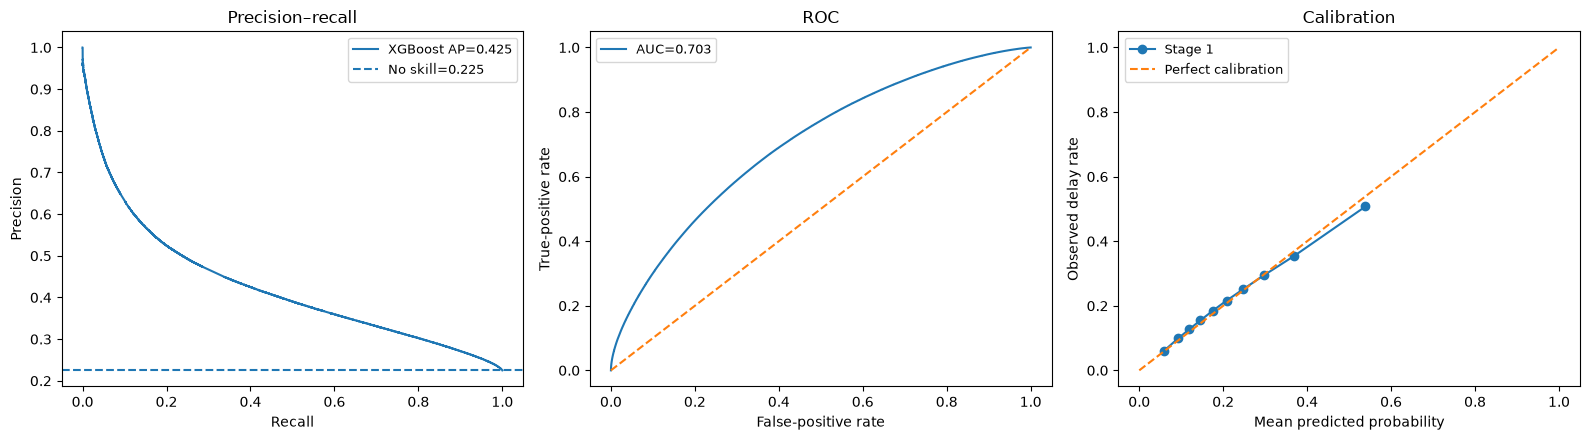

In [9]:
precision, recall, _ = precision_recall_curve(y_valid, p_valid)
fpr, tpr, _ = roc_curve(y_valid, p_valid)
frac_pos, mean_pred = calibration_curve(y_valid, p_valid, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(recall, precision, label=f"XGBoost AP={metrics.loc['Stage 1 XGBoost', 'PR_AUC']:.3f}")
axes[0].axhline(y_valid.mean(), linestyle="--", label=f"No skill={y_valid.mean():.3f}")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision–recall")
axes[0].legend(fontsize=9)

axes[1].plot(fpr, tpr, label=f"AUC={metrics.loc['Stage 1 XGBoost', 'ROC_AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC")
axes[1].legend(fontsize=9)

axes[2].plot(mean_pred, frac_pos, marker="o", label="Stage 1")
axes[2].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
axes[2].set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="Calibration")
axes[2].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03b_validation_curves.png", bbox_inches="tight")
plt.show()

- Reduced gap for larger probability bins.

## 7. Diagnostic operating threshold

For the binary classifier, report the 2025 threshold that maximizes F1 as a
diagnostic benchmark. The final operating threshold should reflect the intended
alert volume or error costs and must be frozen before final 2026 scoring.

In [10]:
pr_precision, pr_recall, thresholds = precision_recall_curve(y_valid, p_valid)
f1 = 2 * pr_precision[:-1] * pr_recall[:-1] / np.maximum(pr_precision[:-1] + pr_recall[:-1], 1e-12)
best_idx = int(np.nanargmax(f1))
best_threshold = float(thresholds[best_idx])


def threshold_metrics(threshold: float) -> dict[str, float | int]:
    pred = p_valid >= threshold
    tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel()
    return {
        "threshold": threshold,
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "predicted_positive_rate": pred.mean(),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


threshold_table = pd.DataFrame([
    threshold_metrics(t) for t in sorted(set([0.10, 0.20, 0.30, 0.40, 0.50, best_threshold]))
])
print(f"Diagnostic max-F1 threshold: {best_threshold:.3f}")
print(threshold_table.round(3).to_string(index=False))

Diagnostic max-F1 threshold: 0.217
 threshold  precision  recall  specificity  predicted_positive_rate      TP      FP      FN      TN
     0.100      0.257   0.940        0.210                    0.824 1459797 4220570   92356 1124288
     0.200      0.332   0.696        0.594                    0.472 1080246 2172478  471907 3172380
     0.217      0.345   0.650        0.642                    0.424 1009355 1915287  542798 3429571
     0.300      0.409   0.444        0.814                    0.244  689010  994488  863143 4350370
     0.400      0.490   0.255        0.923                    0.117  395875  412690 1156278 4932168
     0.500      0.584   0.136        0.972                    0.052  210737  150327 1341416 5194531


Experiment 3
- precision = 34.2%
- recall = 65.5%
- specificity = 63.4%
- predicted-positive rate = 43.1%


## 8. Temporal stability within 2025

A useful Stage 1 model should beat the monthly prevalence baseline throughout
the year, not only in aggregate. Large changes in PR-AUC, Brier score or mean
prediction indicate drift or poor calibration in specific months.

 period  flights  actual_rate  mean_prediction  PR_AUC  ROC_AUC  Brier
2025-01   523167       0.1893           0.2356  0.3836   0.6895 0.1428
2025-02   497343       0.2090           0.2202  0.4310   0.7059 0.1472
2025-03   593741       0.1978           0.2268  0.3654   0.6868 0.1478
2025-04   578961       0.1983           0.2044  0.3832   0.6926 0.1451
2025-05   599192       0.2381           0.2572  0.4379   0.6985 0.1640
2025-06   601662       0.2852           0.2503  0.5099   0.7189 0.1795
2025-07   615731       0.2922           0.3073  0.5013   0.7086 0.1843
2025-08   595815       0.2283           0.2240  0.4254   0.7026 0.1587
2025-09   559481       0.1680           0.1506  0.3246   0.6930 0.1299
2025-10   602559       0.2045           0.1661  0.3818   0.6949 0.1507
2025-11   556244       0.2070           0.1979  0.3861   0.6933 0.1500
2025-12   573115       0.2692           0.2547  0.4706   0.6923 0.1772


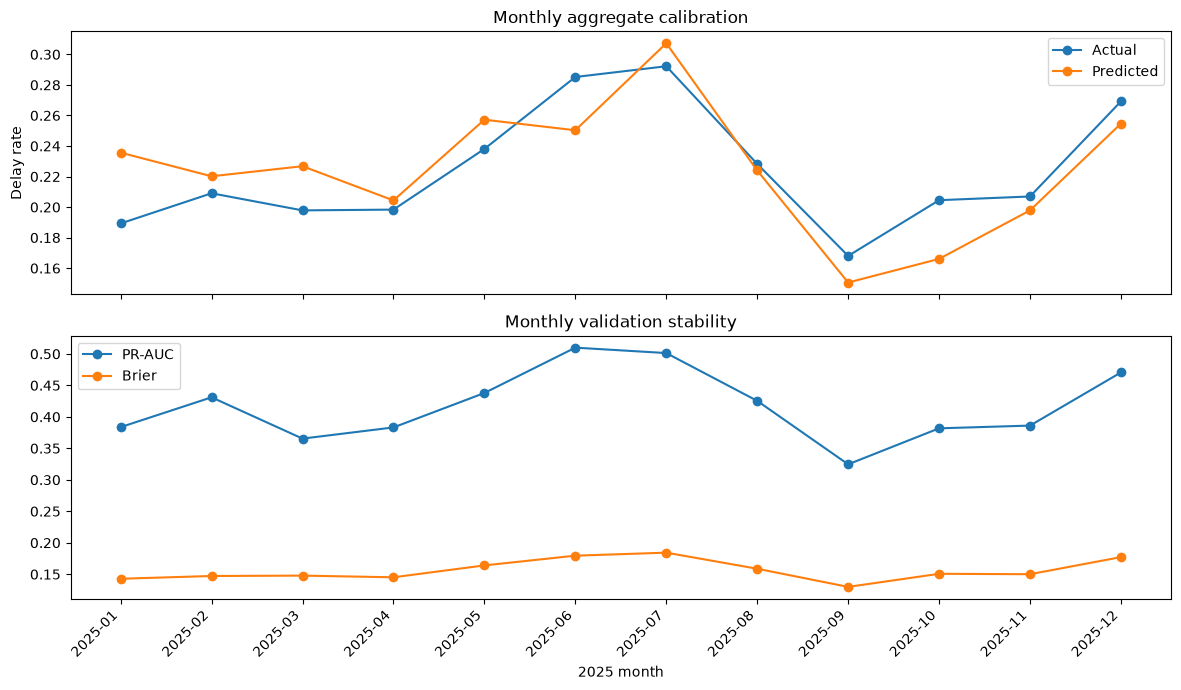

In [11]:
validation_results = valid_meta.reset_index(drop=True).assign(
    y_true=np.asarray(y_valid),
    p_delay=p_valid,
)
validation_results["period"] = pd.to_datetime(validation_results["FlightDate"]).dt.to_period("M").astype(str)

monthly = []
for period, group in validation_results.groupby("period", observed=True):
    monthly.append({
        "period": period,
        "flights": len(group),
        "actual_rate": group["y_true"].mean(),
        "mean_prediction": group["p_delay"].mean(),
        "PR_AUC": average_precision_score(group["y_true"], group["p_delay"]),
        "ROC_AUC": roc_auc_score(group["y_true"], group["p_delay"]),
        "Brier": brier_score_loss(group["y_true"], group["p_delay"]),
    })
monthly = pd.DataFrame(monthly)
print(monthly.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["actual_rate"], marker="o", label="Actual")
axes[0].plot(monthly["period"], monthly["mean_prediction"], marker="o", label="Predicted")
axes[0].set(ylabel="Delay rate", title="Monthly aggregate calibration")
axes[0].legend()
axes[1].plot(monthly["period"], monthly["PR_AUC"], marker="o", label="PR-AUC")
axes[1].plot(monthly["period"], monthly["Brier"], marker="o", label="Brier")
axes[1].set(xlabel="2025 month", title="Monthly validation stability")
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03b_monthly_validation.png", bbox_inches="tight")
plt.show()

- Adding national short-term delay pressure improves temporal calibration,
  especially around the summer peak.
- Experiment 3 substantially overpredicted July, whereas Experiment 3b reduces
  the July calibration gap to roughly 1–2 percentage points.
- The pressure feature helps distinguish a high-delay operating regime from one
  that is actively worsening: by July, the 7-day and 28-day national rates were
  similar even though both remained elevated.
- August is also closely calibrated, supporting the idea that the model responds
  more appropriately as conditions move away from the summer peak.
- Some temporal drift remains. January is overpredicted, while June, September,
  October, and December are underpredicted; October remains the largest
  late-year calibration gap. Strong aggregate calibration does not imply perfect calibration
  within every month.

 period  actual_rate  mean_prediction  calibration_gap  pr_auc_lift  brier_skill
2025-01       0.1893           0.2356           0.0464       2.0269       0.0694
2025-02       0.2090           0.2202           0.0111       2.0618       0.1097
2025-03       0.1978           0.2268           0.0289       1.8470       0.0687
2025-04       0.1983           0.2044           0.0060       1.9319       0.0872
2025-05       0.2381           0.2572           0.0192       1.8392       0.0957
2025-06       0.2852           0.2503          -0.0349       1.7879       0.1196
2025-07       0.2922           0.3073           0.0150       1.7155       0.1091
2025-08       0.2283           0.2240          -0.0043       1.8636       0.0989
2025-09       0.1680           0.1506          -0.0174       1.9316       0.0708
2025-10       0.2045           0.1661          -0.0384       1.8665       0.0739
2025-11       0.2070           0.1979          -0.0091       1.8656       0.0858
2025-12       0.2692        

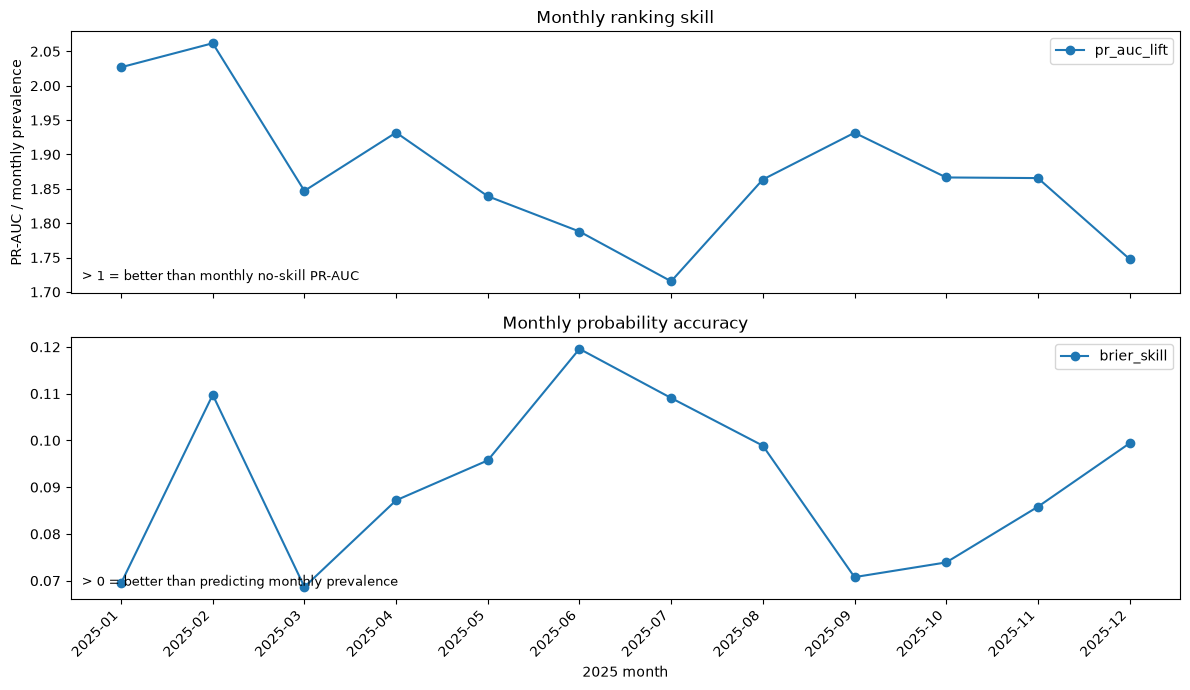

In [12]:
# Raw monthly PR-AUC partly changes with monthly delay prevalence. Check PR_AUC / prevalence.
# Brier score also depends on prevalence. A lower Brier score in a low-delay month does not 
# automatically mean better model performance. Evaluate with a month-specific prevalence baseline.

monthly["calibration_gap"] = (
    monthly["mean_prediction"] - monthly["actual_rate"]
)
monthly["pr_auc_lift"] = (
    monthly["PR_AUC"] / monthly["actual_rate"]
)
monthly["baseline_brier"] = (
    monthly["actual_rate"] * (1 - monthly["actual_rate"])
)
monthly["brier_skill"] = (
    1 - monthly["Brier"] / monthly["baseline_brier"]
)
print(
    monthly[
        [
            "period",
            "actual_rate",
            "mean_prediction",
            "calibration_gap",
            "pr_auc_lift",
            "brier_skill",
        ]
    ].round(4).to_string(index=False)
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["pr_auc_lift"], marker="o", label="pr_auc_lift")
axes[0].set(ylabel="PR-AUC / monthly prevalence", title="Monthly ranking skill")
axes[0].text(
    0.01, 0.05,
    "> 1 = better than monthly no-skill PR-AUC",
    transform=axes[0].transAxes,
    fontsize=9,
)
axes[0].legend()
axes[1].plot(monthly["period"], monthly["brier_skill"], marker="o", label="brier_skill")
axes[1].set(xlabel="2025 month", title="Monthly probability accuracy")
axes[1].text(
    0.01, 0.05,
    "> 0 = better than predicting monthly prevalence",
    transform=axes[1].transAxes,
    fontsize=9,
)
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03b_monthly_skill.png", bbox_inches="tight")
plt.show()

## 9. Gain importance and saved development artifacts

Gain importance is a model-debugging view, not the final interpretation. SHAP
and permutation importance are run after the Stage 1 specification is accepted.

In [13]:
importance = (
    pd.Series(
        model.get_booster().get_score(importance_type="gain"),
        name="gain",
    )
    .rename_axis("feature")
    .reset_index()
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
importance["gain_share"] = importance["gain"] / importance["gain"].sum()
importance["cumulative_gain_share"] = importance["gain_share"].cumsum()

print(
    importance[
        ["feature", "gain", "gain_share", "cumulative_gain_share"]
    ].head(20).to_string(
        index=False,
        formatters={
            "gain": "{:,.1f}".format,
            "gain_share": "{:.1%}".format,
            "cumulative_gain_share": "{:.1%}".format,
        },
    )
)

                      feature    gain gain_share cumulative_gain_share
         origin_frozen_precip 1,504.2      16.1%                 16.1%
          origin_thunderstorm 1,039.6      11.1%                 27.2%
               sched_dep_hour   664.8       7.1%                 34.3%
            dest_thunderstorm   609.5       6.5%                 40.8%
             origin_precip_3h   523.0       5.6%                 46.4%
       carrier_delay_rate_28d   385.0       4.1%                 50.6%
       origin_ifr_hours_past3   352.7       3.8%                 54.3%
         dest_flight_category   271.8       2.9%                 57.2%
  hist_origin_hour_delay_rate   260.3       2.8%                 60.0%
hist_carrier_route_delay_rate   257.2       2.8%                 62.8%
           dest_frozen_precip   234.4       2.5%                 65.3%
            next_holiday_name   219.5       2.3%                 67.6%
       national_delay_rate_7d   196.7       2.1%                 69.7%
      

### 9.1 TreeSHAP global importance

Identify which features make the largest contributions to its 2025 validation predictions. Sampling keeps the computation practical without changing the fitted model.

In [18]:
SHAP_SAMPLE_N = 50_000
shap_sample = X_valid.sample(
    n=min(SHAP_SAMPLE_N, len(X_valid)),
    random_state=RANDOM_STATE,
).copy()

shap_dmatrix = DMatrix(shap_sample, enable_categorical=True)
shap_contrib = model.get_booster().predict(
    shap_dmatrix,
    pred_contribs=True,
    approx_contribs=False,
    validate_features=True,
)

if shap_contrib.shape[1] != len(FEATURES) + 1:
    raise AssertionError(
        "TreeSHAP output should contain one contribution per feature plus the bias term"
    )

shap_values = shap_contrib[:, :-1]
shap_base_values = shap_contrib[:, -1]

# TreeSHAP contributions should reconstruct the raw XGBoost margin.
raw_margin = model.get_booster().predict(
    shap_dmatrix,
    output_margin=True,
    validate_features=True,
)
max_additivity_error = float(
    np.max(np.abs(raw_margin - (shap_base_values + shap_values.sum(axis=1))))
)
print(f"SHAP sample rows: {len(shap_sample):,}")
print(f"Max TreeSHAP additivity error: {max_additivity_error:.3e}")

shap_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
})
shap_importance = shap_importance.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
shap_importance["shap_share"] = (
    shap_importance["mean_abs_shap"] / shap_importance["mean_abs_shap"].sum()
)
shap_importance["cumulative_shap_share"] = shap_importance["shap_share"].cumsum()

print("\nTop TreeSHAP model drivers")
print(
    shap_importance.head(20).to_string(
        index=False,
        formatters={
            "mean_abs_shap": "{:.4f}".format,
            "shap_share": "{:.1%}".format,
            "cumulative_shap_share": "{:.1%}".format,
        },
    )
)

SHAP sample rows: 50,000
Max TreeSHAP additivity error: 5.007e-06

Top TreeSHAP model drivers
                          feature mean_abs_shap shap_share cumulative_shap_share
                   sched_dep_hour        0.3351      16.1%                 16.1%
      hist_origin_hour_delay_rate        0.1178       5.7%                 21.8%
    hist_carrier_route_delay_rate        0.1065       5.1%                 27.0%
                             Dest        0.1041       5.0%                 32.0%
           national_delay_rate_7d        0.1025       4.9%                 36.9%
                           Origin        0.0999       4.8%                 41.7%
           carrier_delay_rate_28d        0.0994       4.8%                 46.5%
                        DayOfWeek        0.0793       3.8%                 50.3%
             dest_flight_category        0.0786       3.8%                 54.1%
             days_to_next_holiday        0.0683       3.3%                 57.4%
               

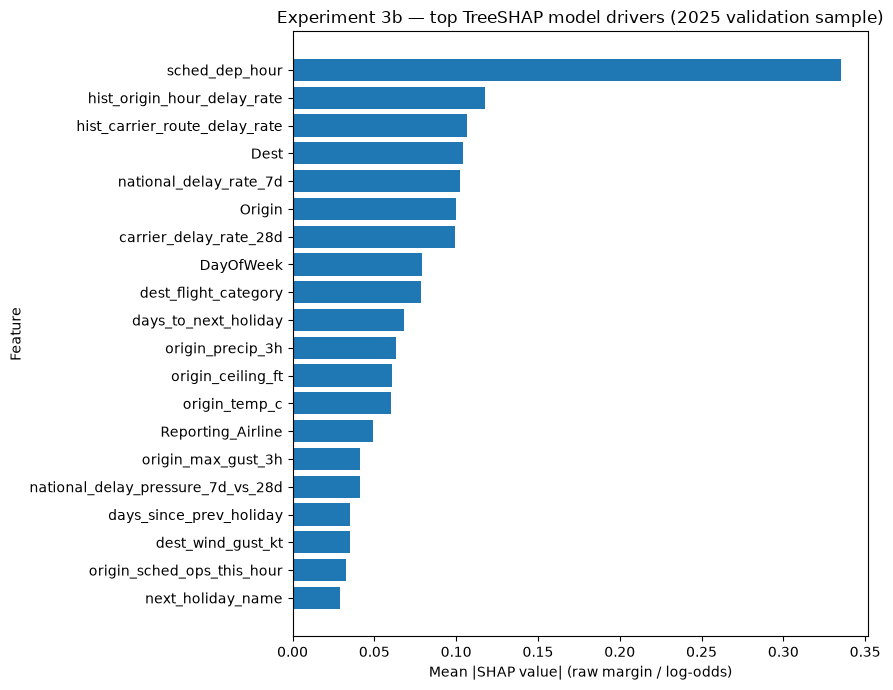

In [19]:
plot_shap = shap_importance.head(20).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_shap["feature"], plot_shap["mean_abs_shap"])
ax.set(
    xlabel="Mean |SHAP value| (raw margin / log-odds)",
    ylabel="Feature",
    title="Experiment 3b — top TreeSHAP model drivers (2025 validation sample)",
)
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03b_shap_importance.png", bbox_inches="tight")
plt.show()

## 10. Save comparable experiment artifacts

These files can be concatenated with other experiment outputs for cross-experiment evaluation later.

In [15]:
model_path = MODELS / f"{ROBUST_MODEL_NAME}.json"
metadata_path = MODELS / f"{ROBUST_MODEL_NAME}_metadata.json"
history_path = MODELS / f"{ROBUST_MODEL_NAME}_historical_state.joblib"
model.save_model(model_path)
joblib.dump(historical_state, history_path)
metadata = {
    "train_year": TRAIN_YEAR,
    "validation_year": VALID_YEAR,
    "features": FEATURES,
    "categorical_features": CATEGORICAL,
    "historical_feature_specs": [
        {"name": name, "columns": list(columns), "smoothing": smoothing}
        for name, columns, smoothing in DEFAULT_HISTORICAL_RATE_SPECS
    ],
    "historical_global_rate": float(historical_state["global_rate"]),
    "best_iteration": int(model.best_iteration),
    "diagnostic_f1_threshold": best_threshold,
    "validation_metrics": metrics.loc["Stage 1 XGBoost"].to_dict(),
}
metadata_path.write_text(json.dumps(metadata, indent=2))
print(f"Saved model      : {model_path}")
print(f"Saved history    : {history_path}")
print(f"Saved metadata   : {metadata_path}")

Saved model      : models/stage1_xgb_2024_to_2025_03b.json
Saved history    : models/stage1_xgb_2024_to_2025_03b_historical_state.joblib
Saved metadata   : models/stage1_xgb_2024_to_2025_03b_metadata.json


## Improvements

Hyperparameter tuning.

max_depth=8, min_child_weight=20, subsample=0.85, colsample_bytree=0.85, reg_alpha=0.05, and reg_lambda=5, learning_rate=0.05, n_estimators=3_000, and early_stopping_rounds=100

1. Tree complexity first with min_child_weight: reduce complexity? [4,6,8], [20, 50, 100]
2. Tune regularization: stronger L1 (reg_alpha) and L2 (reg_lambda)? [0, 0.05, 0.10, 0.25], [2, 5, 10, 20]
3. Learning rate: [0.03, 0.05, 0.08]
4. n_estimator: increase n_estimator and let early stopping take over
5. We use the above validation method to find the best model and score on 2026 data.